In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt 
import cv2
import json
import numpy as np
from pathlib import Path

**Segmentation Test** 

Apply the segmentation model to an image and visualize the results.

In [ ]:
# Load the model (if the model is not available, it will be downloaded automatically)
model_name = "yolo26s-seg"  
model = YOLO(f"./weights/{model_name}.pt")

# get the results for the image
results = model.predict("data/aula-extended.png", conf=0.1, classes=[0])  # class 0 corresponds to 'person'  
result = results[0]


# plot the results
plt.figure(figsize=(15, 7))

# Convert the annotated image from BGR to RGB for correct color display in Matplotlib
annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

plt.title(f"{model_name} - Segmentation Results")
plt.imshow(annotated_img_rgb)
plt.xlabel(f"Detections: {len(result.boxes)}")
plt.tight_layout()
plt.show()

**Visualize the Mask**

Visualize the precomputed segmentation mask of the seats inside the scene.

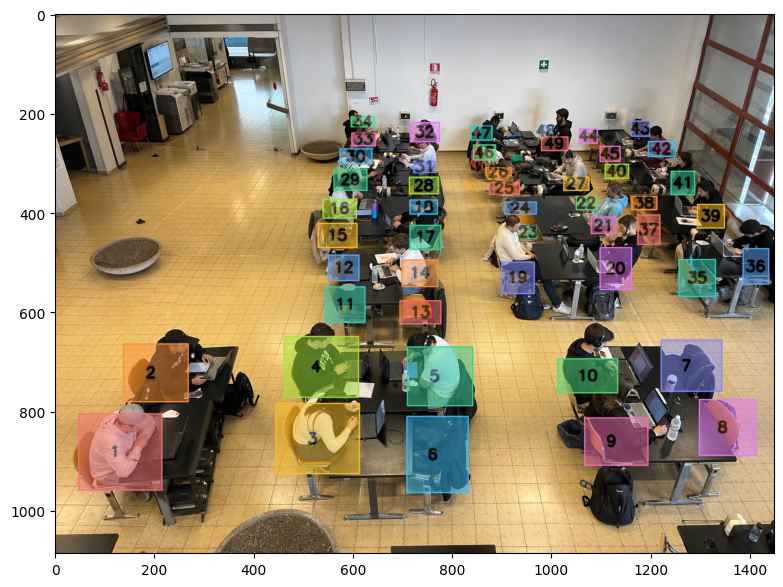

In [63]:
def visualize_mask(image_path: str, mask_path: str, json_path: str) -> np.ndarray:
    """
    Visualize the seat mask overlayed on the original image, with filled transparent rectangles.
    """
    
    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"Image not found: {image_path}")

    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        raise FileNotFoundError(f"Mask not found: {mask_path}")

    with open(json_path, 'r') as f:
        seats_data = json.load(f)
    
    seats_list = seats_data['seats']
    
    # image overlay for rectangles background
    overlay = image.copy()
    # image overlay for rectangles borders 
    output = image.copy()
    
    for seat in seats_list:
        seat_color_hex = seat['color']
        seat_id = seat['id']
        
        # Convert HEX (#RRGGBB) to BGR (OpenCV format)
        r = int(seat_color_hex[1:3], 16)
        g = int(seat_color_hex[3:5], 16)
        b = int(seat_color_hex[5:7], 16)
        seat_color_bgr = (b, g, r)

        # Get the bounding box coordinates
        x_coords = [pt['x'] for pt in seat['points']]
        y_coords = [pt['y'] for pt in seat['points']]
        x_min, x_max = int(min(x_coords)), int(max(x_coords))
        y_min, y_max = int(min(y_coords)), int(max(y_coords))
        
        # Draw the filled rectangle on the overlay
        cv2.rectangle(overlay, (x_min, y_min), (x_max, y_max), seat_color_bgr, thickness=-1)
        # Draw the border on the output copy to keep it visible 
        cv2.rectangle(output, (x_min, y_min), (x_max, y_max), seat_color_bgr, thickness=2)
        
        # Add the seat ID inside and over the rectangle  
        cv2.putText(overlay, 
                    str(seat_id),
                    ((x_min // 2 + x_max // 2) - 20, (y_min // 2 + y_max // 2) + 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 
                    1, (0, 0, 0), 3, cv2.LINE_AA)

    alpha = 0.5  # transparency factor (0.0 - fully transparent, 1.0 - fully opaque)
    # Blend the overlay with the output image using the specified alpha for transparency
    # formula: output * (1 - alpha) + overlay * alpha
    cv2.addWeighted(overlay, alpha, output, 1 - alpha, 0, output)
    
    return output

result = visualize_mask(
    image_path="data/aula-extended.png",
    mask_path="mask/seat_mask.png",
    json_path="mask/seats.json",
)

plt.figure(figsize=(15, 7))
result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)
plt.imshow(result_rgb)
plt.show()